<a href="https://colab.research.google.com/github/Eliezer-Carvalho/Tiny-Transformer/blob/main/tiny_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transformers**
<hr>

Os Transformers são uma arquitetura de Redes Neurais baseada no mecanismo <b> Attention</b>. <br>
Esta abordagem foi proposta em 2017 no artigo <b><i> ["Attention Is All You Need"](https://arxiv.org/pdf/1706.03762) </i></b> e desde então revolucionou o campo da Inteligência Artificial. <br>
Uma das maiores provas do impacto dos Transformers é o surgimento de modelos como: <br>

*    <b> [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer) <i>(Generative Pre-trained Transformer)</i> </b>
*    <b> [BERT](https://en.wikipedia.org/wiki/BERT_(language_model)) <i>(Bidirectional Encoder Representations from Transformers)</i></b>.









O objetivo deste Google Colab é explorar de forma sucinta e prática a arquitetura dos Transformers. <br>
Ao longo do notebook, iremos percorrer os seus principais componentes construindo gradualmente a intuição por trás do modelo. <br>

No final, teremos a implementação de um <b>Transformer Decoder</b> simplificado, baseado em <b>Single Head Attention</b>, permitindo compreender de forma clara os fundamentos desta arquitetura.


---



### <b> 1. Tokenização </b>
Como a arquitetura Transformer consiste em operações sobre números, deve haver primeiro um mapeamento de qualquer texto de entrada para representação numérica. <br>
Este processo ocorre em três etapas principais: <br>


1.   <b> Pré Tokenizer </b> - o texto é dividido em unidades iniciais (pré-tokens). (existem vários tipos de Pré Tokenizer's)
2.   <b> Tokenizer </b> - cada pré-token é segmentado em tokens, que pertencem a um vocabulário finito e são associados a um identificador único. Permite representar o texto como uma sequência de números. (Existem várias técnicas de tokenização.)


Dependendo do tamanho do vocabulário, os tokens podem corresponder a palavras completas ou a <b> subpalavras</b>. <br>
Algoritmos comuns de tokenização incluem <b> BPE (Byte Pair Encoding) </b> ou <b> Unigram Language Model (ULM)</b>. <br>

Hoje em dia, é comum utilizar Tokenizers já pré-treinados, como o SentencePiece ou o TikToken.

<b> No entanto, neste projeto, iremos aprofundar este tema e desenvolver um Tokenizer próprio! </b>





In [382]:
from tokenizers import Tokenizer #https://github.com/huggingface/tokenizers
from tokenizers.models import BPE #https://huggingface.co/docs/tokenizers/index
from tokenizers.pre_tokenizers import Punctuation, Whitespace, Sequence #https://huggingface.co/docs/tokenizers/index
from tokenizers.trainers import BpeTrainer #https://huggingface.co/docs/tokenizers/index
import matplotlib.pyplot as plt #https://huggingface.co/docs/tokenizers/index

#### **Pré Tokenizer**

In [383]:
with open ("Os Lusiadas.txt", "r", encoding = "utf-8") as f:
  doc = f.read()
print (len(doc))
print (doc [:500])

Pre_Tokenizer = Sequence ([Whitespace(), Punctuation()]).pre_tokenize_str (doc)
print (len(Pre_Tokenizer))
print (Pre_Tokenizer  [:500])

313273
OS LUSÍADAS 
Luís de Camões 
Canto I 
As armas e os Barões assinalados Que da Ocidental praia Lusitana Por mares nunca de antes navegados Passaram ainda além da Taprobana, Em perigos e guerras esforçados Mais do que prometia a força humana, E entre gente remota edificaram Novo Reino, que tanto sublimaram; E também as memórias gloriosas Daqueles Reis que foram dilatando A Fé, o Império, e as terras viciosas De África e de Ásia andaram devastando, E aqueles que por obras valerosas Se vão da lei da
67088
[('OS', (0, 2)), ('LUSÍADAS', (3, 11)), ('Luís', (13, 17)), ('de', (18, 20)), ('Camões', (21, 27)), ('Canto', (29, 34)), ('I', (35, 36)), ('As', (38, 40)), ('armas', (41, 46)), ('e', (47, 48)), ('os', (49, 51)), ('Barões', (52, 58)), ('assinalados', (59, 70)), ('Que', (71, 74)), ('da', (75, 77)), ('Ocidental', (78, 87)), ('praia', (88, 93)), ('Lusitana', (94, 102)), ('Por', (103, 106)), ('mares', (107, 112)), ('nunca', (113, 118)), ('de', (119, 121)), ('antes', (122, 127)), ('naveg

#### **Tokenizer**

In [384]:
with open ("Os Lusiadas - Pré Tokenizer.txt", "w", encoding = "utf-8") as f:
  for linha in Pre_Tokenizer:
    f.write (f"{linha} \n")

Tokenizer = Tokenizer(BPE())
Trainer = BpeTrainer (
    vocab_size = 5000, #O tokenizer vai ter um vocabulário com 5000 tokens únicos.
    special_tokens = ["<bos>", "<eos>", "<pad>", "<newline>"] #Tokens especiais, que ajudam o modelo a entender melhor a estrutura dos dados.
)

Tokenizer.train (files = ["Os Lusiadas - Pré Tokenizer.txt"], trainer = Trainer)

In [385]:
Tokenization = Tokenizer.encode (doc)
print (f"Número de Tokens - {len(Tokenization.tokens)}")
print (Tokenization.tokens [:500])

print (f"Número de Ids - {len(Tokenization.ids)}")
print (Tokenization.ids [:500], "\n")

#Guardamos o Tokenizer para podermos usar em qualquer projeto!
Tokenizer.save ("VASCO DA GAMA")

Número de Tokens - 214909
['O', 'S', ' ', 'L', 'U', 'S', 'Í', 'A', 'D', 'A', 'S', ' \n', 'L', 'uí', 's', ' ', 'd', 'e', ' ', 'C', 'am', 'õ', 'es', ' \n', 'C', 'ant', 'o', ' ', 'I', ' \n', 'A', 's', ' ', 'ar', 'm', 'as', ' ', 'e', ' ', 'os', ' ', 'B', 'ar', 'õ', 'es', ' ', 'ass', 'in', 'al', 'ad', 'os', ' ', 'Qu', 'e', ' ', 'd', 'a', ' ', 'O', 'c', 'id', 'ent', 'al', ' ', 'p', 'ra', 'i', 'a', ' ', 'L', 'us', 'it', 'an', 'a', ' ', 'P', 'or', ' ', 'm', 'ar', 'es', ' ', 'n', 'unc', 'a', ' ', 'd', 'e', ' ', 'ant', 'es', ' ', 'n', 'av', 'eg', 'ad', 'os', ' ', 'P', 'ass', 'aram', ' ', 'a', 'ind', 'a', ' ', 'al', 'ém', ' ', 'd', 'a', ' ', 'T', 'ap', 'r', 'ob', 'an', 'a', ', ', 'E', 'm', ' ', 'p', 'er', 'ig', 'os', ' ', 'e', ' ', 'gu', 'er', 'ra', 's', ' ', 'es', 'f', 'orç', 'ad', 'os', ' ', 'M', 'ais', ' ', 'd', 'o', ' ', 'qu', 'e', ' ', 'p', 'r', 'omet', 'i', 'a', ' ', 'a', ' ', 'f', 'orç', 'a', ' ', 'h', 'um', 'an', 'a', ', ', 'E', ' ', 'ent', 're', ' ', 'g', 'ent', 'e', ' ', 'r', 'em', 'ot'

#### **Codificador e Descodificador de um Tokenizer**


In [386]:
Tokenizer = Tokenizer.from_file ("VASCO DA GAMA")

teste = Tokenizer.encode ("Os Lusíadas são épicos")
print ("Codificador:")
print (teste.tokens)
print (teste.ids, "\n")

print ("Descodificador:")
print (Tokenizer.decode(teste.ids))


Codificador:
['O', 's', ' ', 'L', 'us', 'í', 'ad', 'as', ' ', 's', 'ã', 'o', ' ', 'é', 'p', 'ic', 'os']
[40, 69, 5, 37, 291, 96, 227, 177, 5, 69, 89, 65, 5, 92, 66, 448, 142] 

Descodificador:
O s   L us í ad as   s ã o   é p ic os


#### **Espaço Dimensional de um Tokenizer**


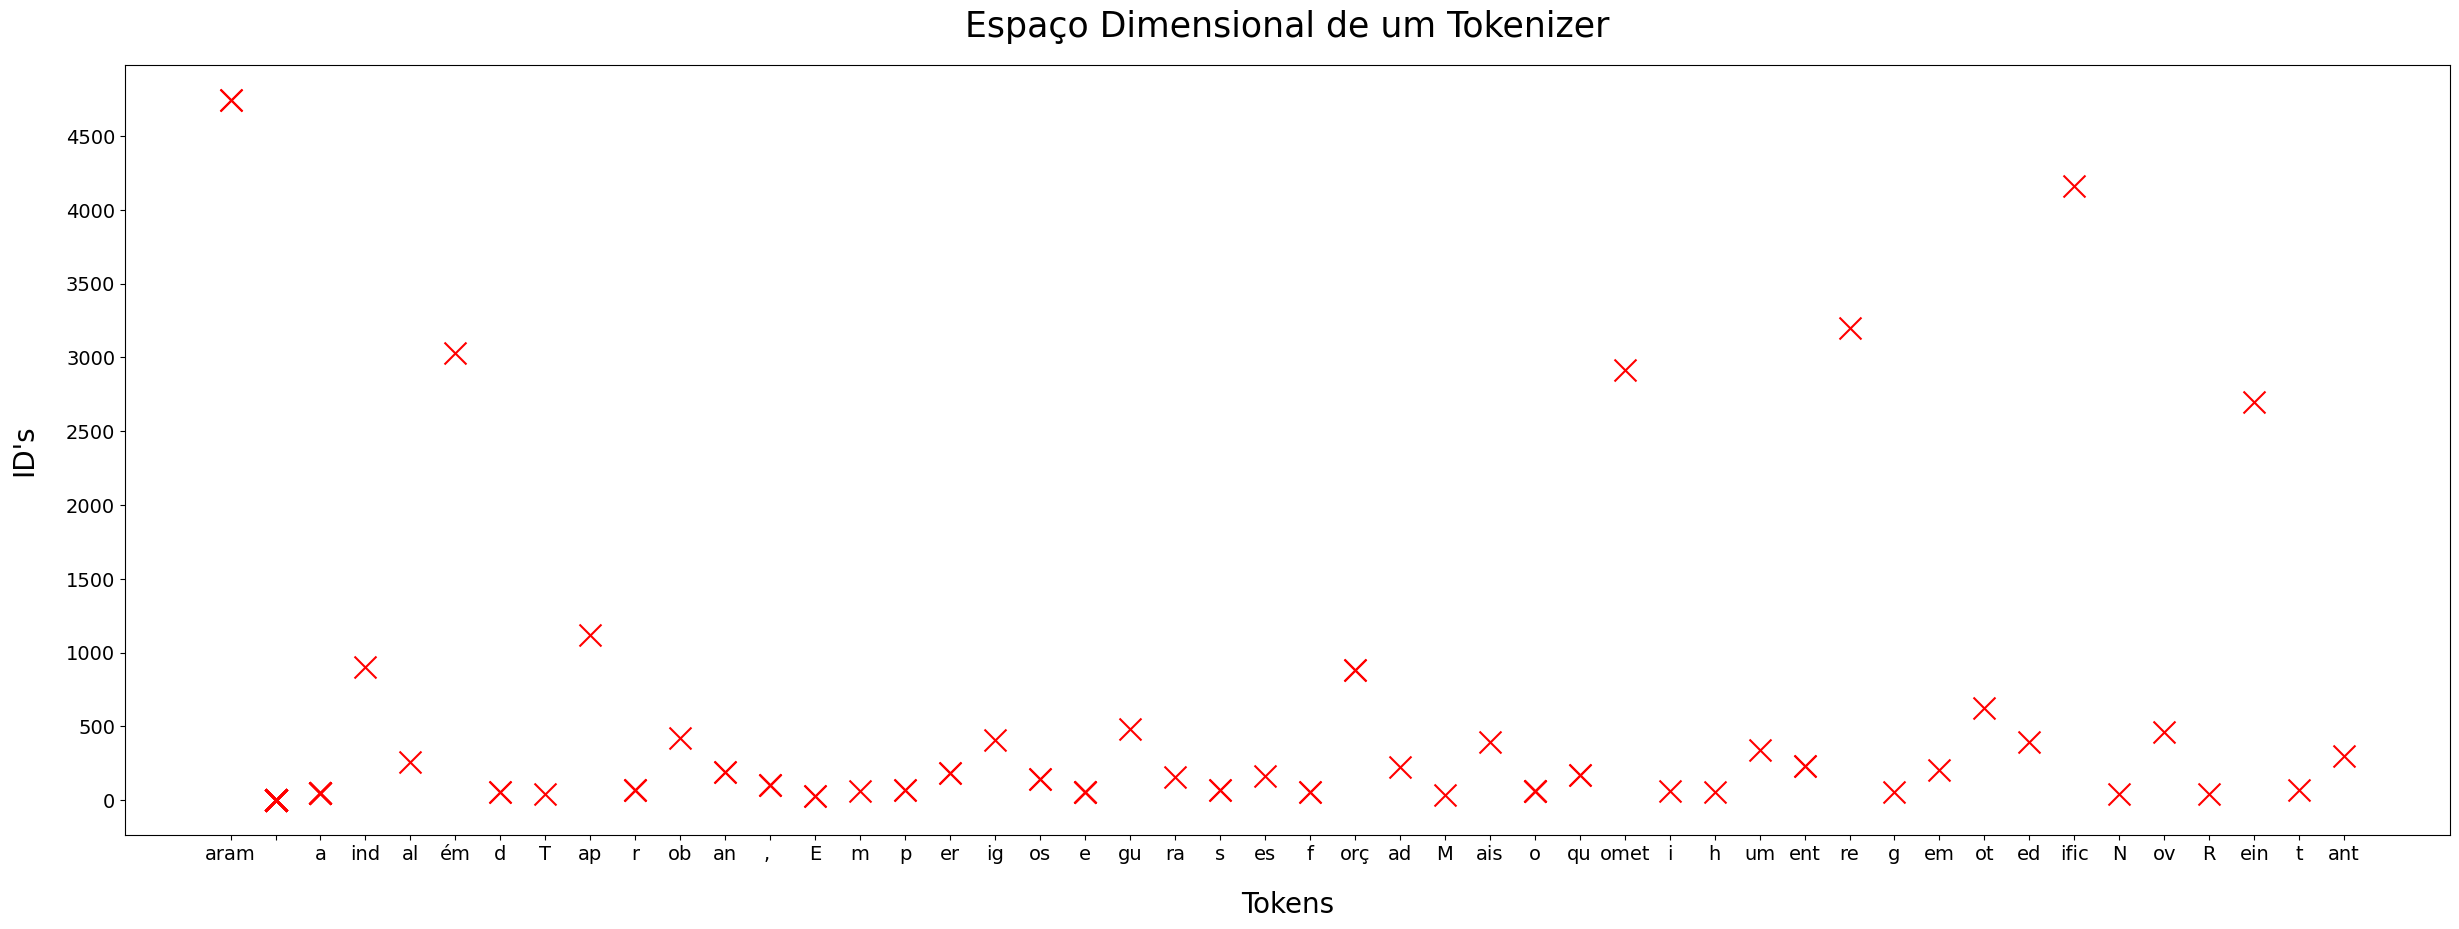

In [387]:
plt.figure (figsize = (30, 10))
plt.scatter (Tokenization.tokens [100:200], Tokenization.ids [100:200], marker = "x", color = 'red', s = 250)

plt.xticks (size = 14)
plt.xlabel ("Tokens", size = 20, labelpad = 20)
plt.yticks (list(range(0, 5000, 500)), size = 14)
plt.ylabel ("ID's", size = 20, labelpad = 20)

plt.title ("Espaço Dimensional de um Tokenizer", size = 25, pad = 20)
plt.show()



###


---





### **2. Tensor Shape**

Após a Tokenização, o dataset já se encontra convertido para uma representação numérica. <br>
A organização dos dados de entrada é feita através da definição de dois parâmetros fundamentais: <br>


1.   **Batch Size** - número de sequências processadas em paralelo durante o treino.
2.   **Sequence Length** - número de tokens considerados em cada sequência.


Esta abordagem é necessária porque os Transformers não processam todo o texto de uma vez, mas sim em blocos de tamanho fixo. <br>
De forma análoga à leitura humana, não é possível analisar um texto completo simultaneamente, é necessário dividi-lo em partes para conseguir identificar padrões e relações.

<b> Assim, os dados são representados sob a forma de um tensor com dimensão (B, T). </b>



In [388]:
import torch #https://docs.pytorch.org/docs/stable/index.html
import torch.nn as nn #https://docs.pytorch.org/docs/stable/nn.html
import torch.nn.functional as F #https://docs.pytorch.org/docs/stable/nn.functional.html#torch-nn-functional

#### **Definição do Tensor e Dados de Treino vs Dados de Teste**

In [389]:
tensor = torch.tensor (Tokenization.ids, dtype = torch.long)
print (len(tensor))
print (tensor [:500])

#Divisão de Dados de Treino e Dados de Teste
n = int (0.9 * len(tensor))
dados_treino = tensor [:n] #90% dos dados
dados_teste = tensor [n:] #10% dos dados


214909
tensor([  40,   44,    5,   37,   46,   44,   83,   27,   30,   27,   44,  108,
          37, 2174,   69,    5,   55,   56,    5,   29,  246,  101,  161,  108,
          29,  298,   65,    5,   35,  108,   27,   69,    5,  219,   63,  177,
           5,   56,    5,  142,    5,   28,  219,  101,  161,    5,  541,  233,
         261,  227,  142,    5,  263,   56,    5,   55,   52,    5,   40,   54,
         279,  231,  261,    5,   66,  160,   60,   52,    5,   37,  291,  343,
         189,   52,    5,   41,  194,    5,   63,  219,  161,    5,   64, 1281,
          52,    5,   55,   56,    5,  298,  161,    5,   64,  313,  377,  227,
         142,    5,   41,  541, 4747,    5,   52,  900,   52,    5,  261, 3031,
           5,   55,   52,    5,   45, 1119,   68,  420,  189,   52,  106,   31,
          63,    5,   66,  183,  409,  142,    5,   56,    5,  484,  183,  160,
          69,    5,  161,   57,  881,  227,  142,    5,   38,  394,    5,   55,
          65,    5,  172,   56,  

#### **Tensor (B, T)**

In [390]:
Batch_Size = 4
Sequence_Length = 8
torch.manual_seed (1000)

posição = torch.randint (0, len (dados_treino) - Sequence_Length, (Batch_Size, ))
x = torch.stack ([dados_treino [i:i + Sequence_Length] for i in posição])
y = torch.stack ([dados_treino [i + 1: i + Sequence_Length + 1] for i in posição])

print (x.shape) #(B, T)
print (x)
print (y.shape) #(B, T)
print (y)

#mais para a frente
sda = x

torch.Size([4, 8])
tensor([[1122,  304,   65,    5,   57,  259,   65,    5],
        [  61,   87,    5,   68,  255,  464,   52,  106],
        [  68,  461,  183,   12,   69,   56,    5,   55],
        [ 236,   65,    5, 2305,   56,    5,  263,   56]])
torch.Size([4, 8])
tensor([[ 304,   65,    5,   57,  259,   65,    5,   30],
        [  87,    5,   68,  255,  464,   52,  106,   29],
        [ 461,  183,   12,   69,   56,    5,   55,   56],
        [  65,    5, 2305,   56,    5,  263,   56,    5]])


###


---



### <b> 3. Embedding </b>

Word Embeddings são representações vetoriais de palavras.

Normalmente, cada token é mapeado para um <b> vetor de valores reais</b>, onde a sua posição no espaço vetorial reflete o seu significado. Palavras com significados semelhantes tendem a estar próximas nesse espaço, permitindo ao modelo capturar relações semânticas entre elas.

Neste ponto, introduz-se uma das variáveis fundamentais de uma arquitetura Transformer:


1.   <b> Embedding Dimension </b> - Define a dimensão dos vetores utilizados para representar cada token e é um dos principais fatores no número total de parâmetros do modelo.

Os Embeddings são parâmetros treináveis, ou seja, são ajustados durante o treino do modelo de forma a melhorar a representação dos tokens no espaço vetorial.

<b> Após a aplicação dos Embeddings passamos a ter um tensor com dimensão (B, T, C). </b>

In [391]:
Embedding_Dimension = 16

Embedding = nn.Embedding (Tokenizer.get_vocab_size(), Embedding_Dimension) #Porquê vocab_size ? Vocab_Size dá-nos o número dos tokens únicos que existem.
#Se usássemos por exemplo len(Tokenizer.tokens) não era correto porque estariamos a criar um vetor para tokens repetidos.
x_embedding = Embedding (x)
print (x_embedding.shape) #(B,T,C)
print (x_embedding[0,0]) #Representação vetorial do primeiro token após embedding

torch.Size([4, 8, 16])
tensor([-0.9328, -0.1462,  0.0058, -0.2279,  0.3581, -0.7328,  0.1560,  0.1012,
         2.6806, -1.2006,  1.8497, -0.6988, -1.7417,  0.1064,  0.9392, -0.5493],
       grad_fn=<SelectBackward0>)


#### **Representação dos Tokens e dos seus respetivos Embeddings**
Cada token passa a ser representado por um vetor.

Esta tabela também é excelente para perceber o que <b> nn.Embedding </b> faz por trás.

In [392]:
import pandas as pd

dados = []

for i in range (8):
  dados.append ({
      "Token": x[0,i],
      "Pós Embedding": x_embedding[0,i].detach().cpu().numpy()
  })

df = pd.DataFrame (dados)
print(df.to_string()) #Melhor maneira de mostrar a tabela completa

          Token                                                                                                                                                                                           Pós Embedding
0  tensor(1122)        [-0.9328125, -0.14616692, 0.005843631, -0.22785294, 0.35808286, -0.73282737, 0.15600051, 0.10122411, 2.6805978, -1.2005917, 1.8496885, -0.69875145, -1.7417432, 0.106423, 0.9391876, -0.5492886]
1   tensor(304)           [-0.53223175, -2.947677, 0.7304478, 1.4227643, -0.6754426, 0.6361155, 0.5961184, 0.51830345, -0.12935686, 0.022171494, 0.5766667, 0.91300696, 1.2696129, -0.5945717, -0.27061483, 0.20642594]
2    tensor(65)    [-0.4836936, -0.10018954, -1.2989933, -1.7857331, -1.1012437, -0.32159328, -0.30167744, 0.19776213, 1.7905204, 0.021065904, -0.19988911, -0.13444652, -1.5857627, -0.13060798, 0.7914053, 1.4039313]
3     tensor(5)  [0.118488334, -0.67337835, -0.1437926, 1.9322591, -1.2373394, -0.013671916, -0.09790927, 0.14348322, 0.047022995, 0.657

###


---


### **4. Positional Encoding**

<b>Positional Encoding</b> é uma técnica que adiciona informação sobre a posição de cada token na sequência.

Isto é necessário porque os Transformers, por si só, não processam os tokens de forma sequencial (como as RNNs) e, por isso, não têm noção da ordem das palavras.

Ao introduzir esta informação, o modelo consegue distinguir entre a posição relativa ou absoluta dos tokens, o que é essencial para compreender a estrutura de uma frase e o significado do texto.

A intuição é a seguinte:

* “Rei ama rainha” ≠ “Rainha ama rei” — <b>a ordem importa</b>!

No paper original são utilizados encodings fixos. <br>
No entanto, em muitas implementações modernas, são utilizados positional encodings treináveis, que permitem ao modelo aprender a melhor representação para cada posição durante o treino.

**Neste projeto foram utilizados encodings treináveis.**

In [393]:
Positional_Embedding = nn.Embedding (Sequence_Length, Embedding_Dimension) #Positinal Encoding não é nada mais do que um Embedding
Positional_Encoding = Positional_Embedding (torch.arange (Sequence_Length))
print (Positional_Encoding.shape)



torch.Size([8, 16])


###


---


### **5. Embedding + Positional Encoding**

Neste último passo, antes de introduzirmos o mecanismo <b> Attention</b>, é necessário combinar os Embeddings dos tokens com os Positional Encodings.

Esta combinação é feita através de uma soma elemento a elemento, permitindo que cada token transporte simultaneamente informação sobre o seu significado e a sua posição na sequência.

Este passo é fundamental, pois prepara a representação final que será utilizada pelo mecanismo <b> Attention<b>. Por essa razão, é apresentado como uma etapa separada e de especial importância no fluxo da arquitetura.

In [394]:
x = x_embedding + Positional_Encoding #Dados que vão entrar no modelo
print (x.shape)
x

torch.Size([4, 8, 16])


tensor([[[-2.8768e-01,  3.1593e-01, -3.6064e-02, -1.3158e+00,  4.6584e-01,
          -1.1416e+00, -5.1960e-01,  1.9431e-02,  2.7170e+00, -2.3985e+00,
           1.9454e+00, -7.1700e-01, -8.1187e-01, -7.0517e-01,  6.1672e-01,
          -1.0294e+00],
         [ 3.7194e-01, -3.6311e+00, -4.1100e-01,  1.2521e+00, -7.6906e-01,
          -6.5687e-01,  2.1836e+00, -3.0162e-01, -2.6397e-01, -1.0387e-01,
           1.7055e+00,  9.5855e-01,  1.8202e+00, -6.8824e-01,  9.4462e-01,
           5.4779e-01],
         [-4.6934e-01, -1.3732e+00, -5.5572e-01, -1.7306e+00, -1.0183e+00,
           5.1425e-01,  1.7066e+00, -6.0512e-02,  7.1178e-01, -1.1405e+00,
          -6.3206e-01, -6.2957e-01, -9.6625e-01,  5.9950e-01, -9.9142e-01,
           2.2713e+00],
         [ 4.3085e-01, -2.0873e+00, -1.5404e+00,  3.6318e+00, -1.2022e+00,
           1.4262e+00, -3.4019e-01, -2.6140e+00,  6.7453e-01,  1.2909e+00,
          -2.2228e-01,  2.4109e+00, -4.3420e-01, -5.6198e-01,  9.9549e-01,
          -4.6673e-01],
    

### **6. [Attention](https://medium.com/@nitinmittapally/understanding-attention-in-transformers-a-visual-guide-df416bfe495a)**

<b> Attention </b> é um mecanismo que permite ao modelo focar-se em diferentes partes da sequência de entrada ao processar cada token.

De forma análoga à atenção humana, ao ler uma frase não analisamos cada palavra isoladamente, em vez disso, consideramos o contexto relevante para compreender o significado. <br>
Da mesma forma, o mecanismo de <b> Attention </b> permite ao modelo atribuir diferentes níveis de importância aos vários tokens da sequência, capturando relações e dependências entre eles. <br>
Ao contrário das RNNs, este mecanismo permite acesso direto a todos os Tokens anteriores, facilitando a captura de dependências de longo alcance.

Este é o mecanismo central da arquitetura Transformer e pode ser aplicado de diferentes formas, destacando-se três variantes principais:

*   <b> Self-Attention </b> - cada token atende a todos os outros tokens da mesma sequência, permitindo capturar relações internas.
*   <b> Masked Self-Attention </b> - semelhante ao self-attention, mas com uma máscara que impede o modelo de “ver o futuro”, sendo essencial para tarefas de geração de texto.
*   <b> Cross-Attention </b> - permite relacionar duas sequências diferentes, onde uma sequência atende à outra


<b> Neste Notebook será utilizada a variante Masked Self-Attention, característica de modelos do tipo GPT. </b>

In [395]:
import seaborn as sns

#### <b> Query, Key e Value (Q, K, V) </b>

<b> Attention </b> baseia-se em três representações vetoriais:

* <b> Query (Q) </b> - O que ando à procura ?
* <b> Key (K) </b> - O que ofereço ?
* <b> Value (V) </b> - O meu valor.

A Attention é calculada através da comparação entre <b> Queries </b> e <b> Keys</b>, permitindo determinar o grau de relevância entre tokens. <br>
Esses pesos são depois aplicados aos <b> Values </b> para produzir a saída final. <br>
<b> Vamos ver em código: </b>

In [396]:
B,T,C = x.shape #Batch, Sequence Length, Embedding_Dimension
#print (x.shape)

#C = Embedding_Dimension #Aplica uma Transformação Linear a partir dos Embeddings #Uma projeção desses Embeddings num espaço
Query = nn.Linear (C, C, bias = False)
Key = nn.Linear (C, C, bias = False)
Value = nn.Linear (C, C, bias = False)

#Aplico a projeção nos dados
Q = Query (x) #Y = X * Wq
K = Key (x) #Y = X * Wk
V = Value (x) #Y = X * Wv

print (x.shape)
print (Q.shape)
print (K.shape)
print (V.shape)

torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])


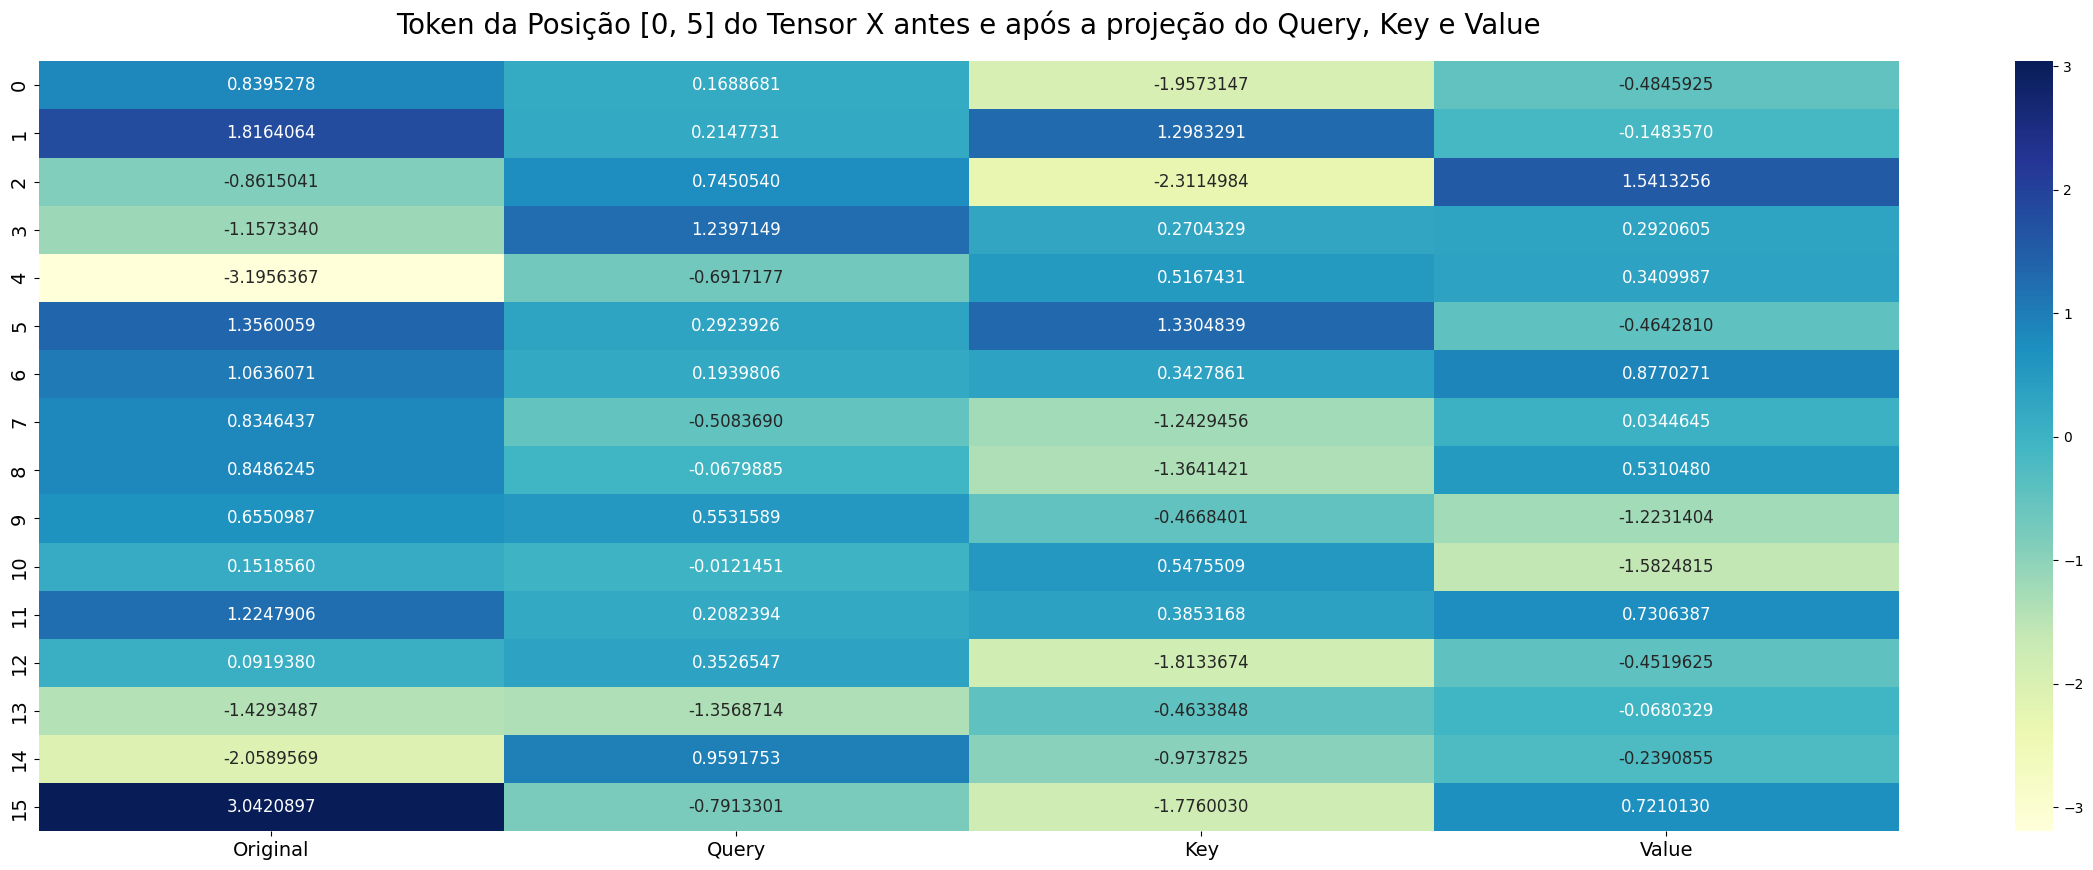

In [397]:
df = pd.DataFrame({
    "Original": x [0,5].detach().numpy(), #x[0,1] vai selecionar um tensor da posição 1 da linha 0 do tensor
    "Query": Q [0,5].detach().numpy(),
    "Key": K [0,5].detach().numpy(),
    "Value": V [0,5].detach().numpy(),
})

plt.figure (figsize = (30, 10))
sns.heatmap(df, cmap = "YlGnBu", annot = True, fmt = ".7f", annot_kws = {"size": 12})

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title("Token da Posição [0, 5] do Tensor X antes e após a projeção do Query, Key e Value", size = 20, pad = 20)
plt.show()


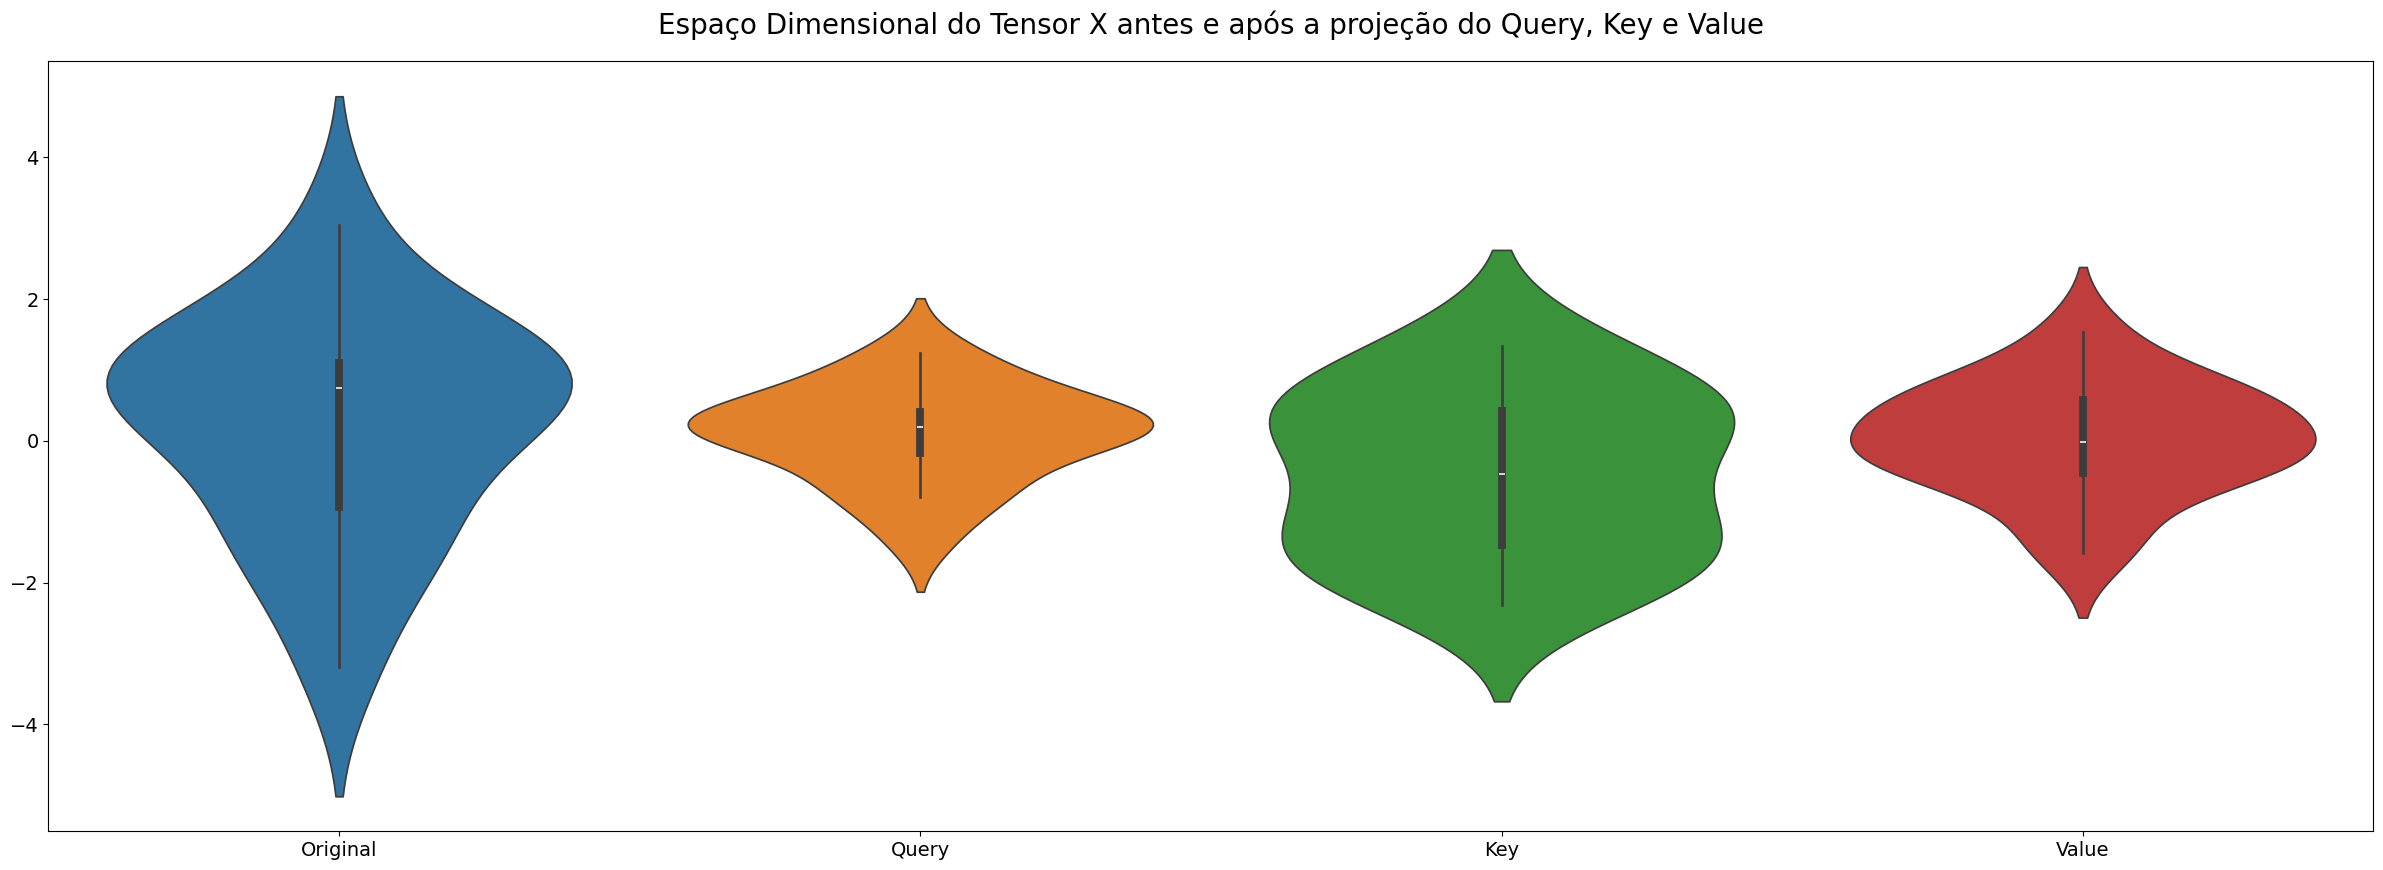

In [398]:
plt.figure (figsize = (30, 10))
sns.violinplot(df, cmap = "YlGnBu")

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title("Espaço Dimensional do Tensor X antes e após a projeção do Query, Key e Value", size = 20, pad = 20)
plt.show()

#### **Scaled Dot-Product Attention (Q @ K)**

**Scaled Dot-Product Attention** é o mecanismo central que permite aos tokens "interagir entre si" dentro de um Transformer.

É aqui que deixa de haver apenas transformações individuais (Q, K, V) e passa a haver comunicação entre tokens.

**É um produto de vetores super simples!**


In [399]:
product_attention = Q @ K.transpose (-2, -1) #(B, T, C) @ (B ,C ,T) --> (B, T, T)
product_attention = F.softmax (product_attention, dim = -1) #Softmax para normalizar #A soma dos valores dá 1

print (product_attention.shape)

torch.Size([4, 8, 8])


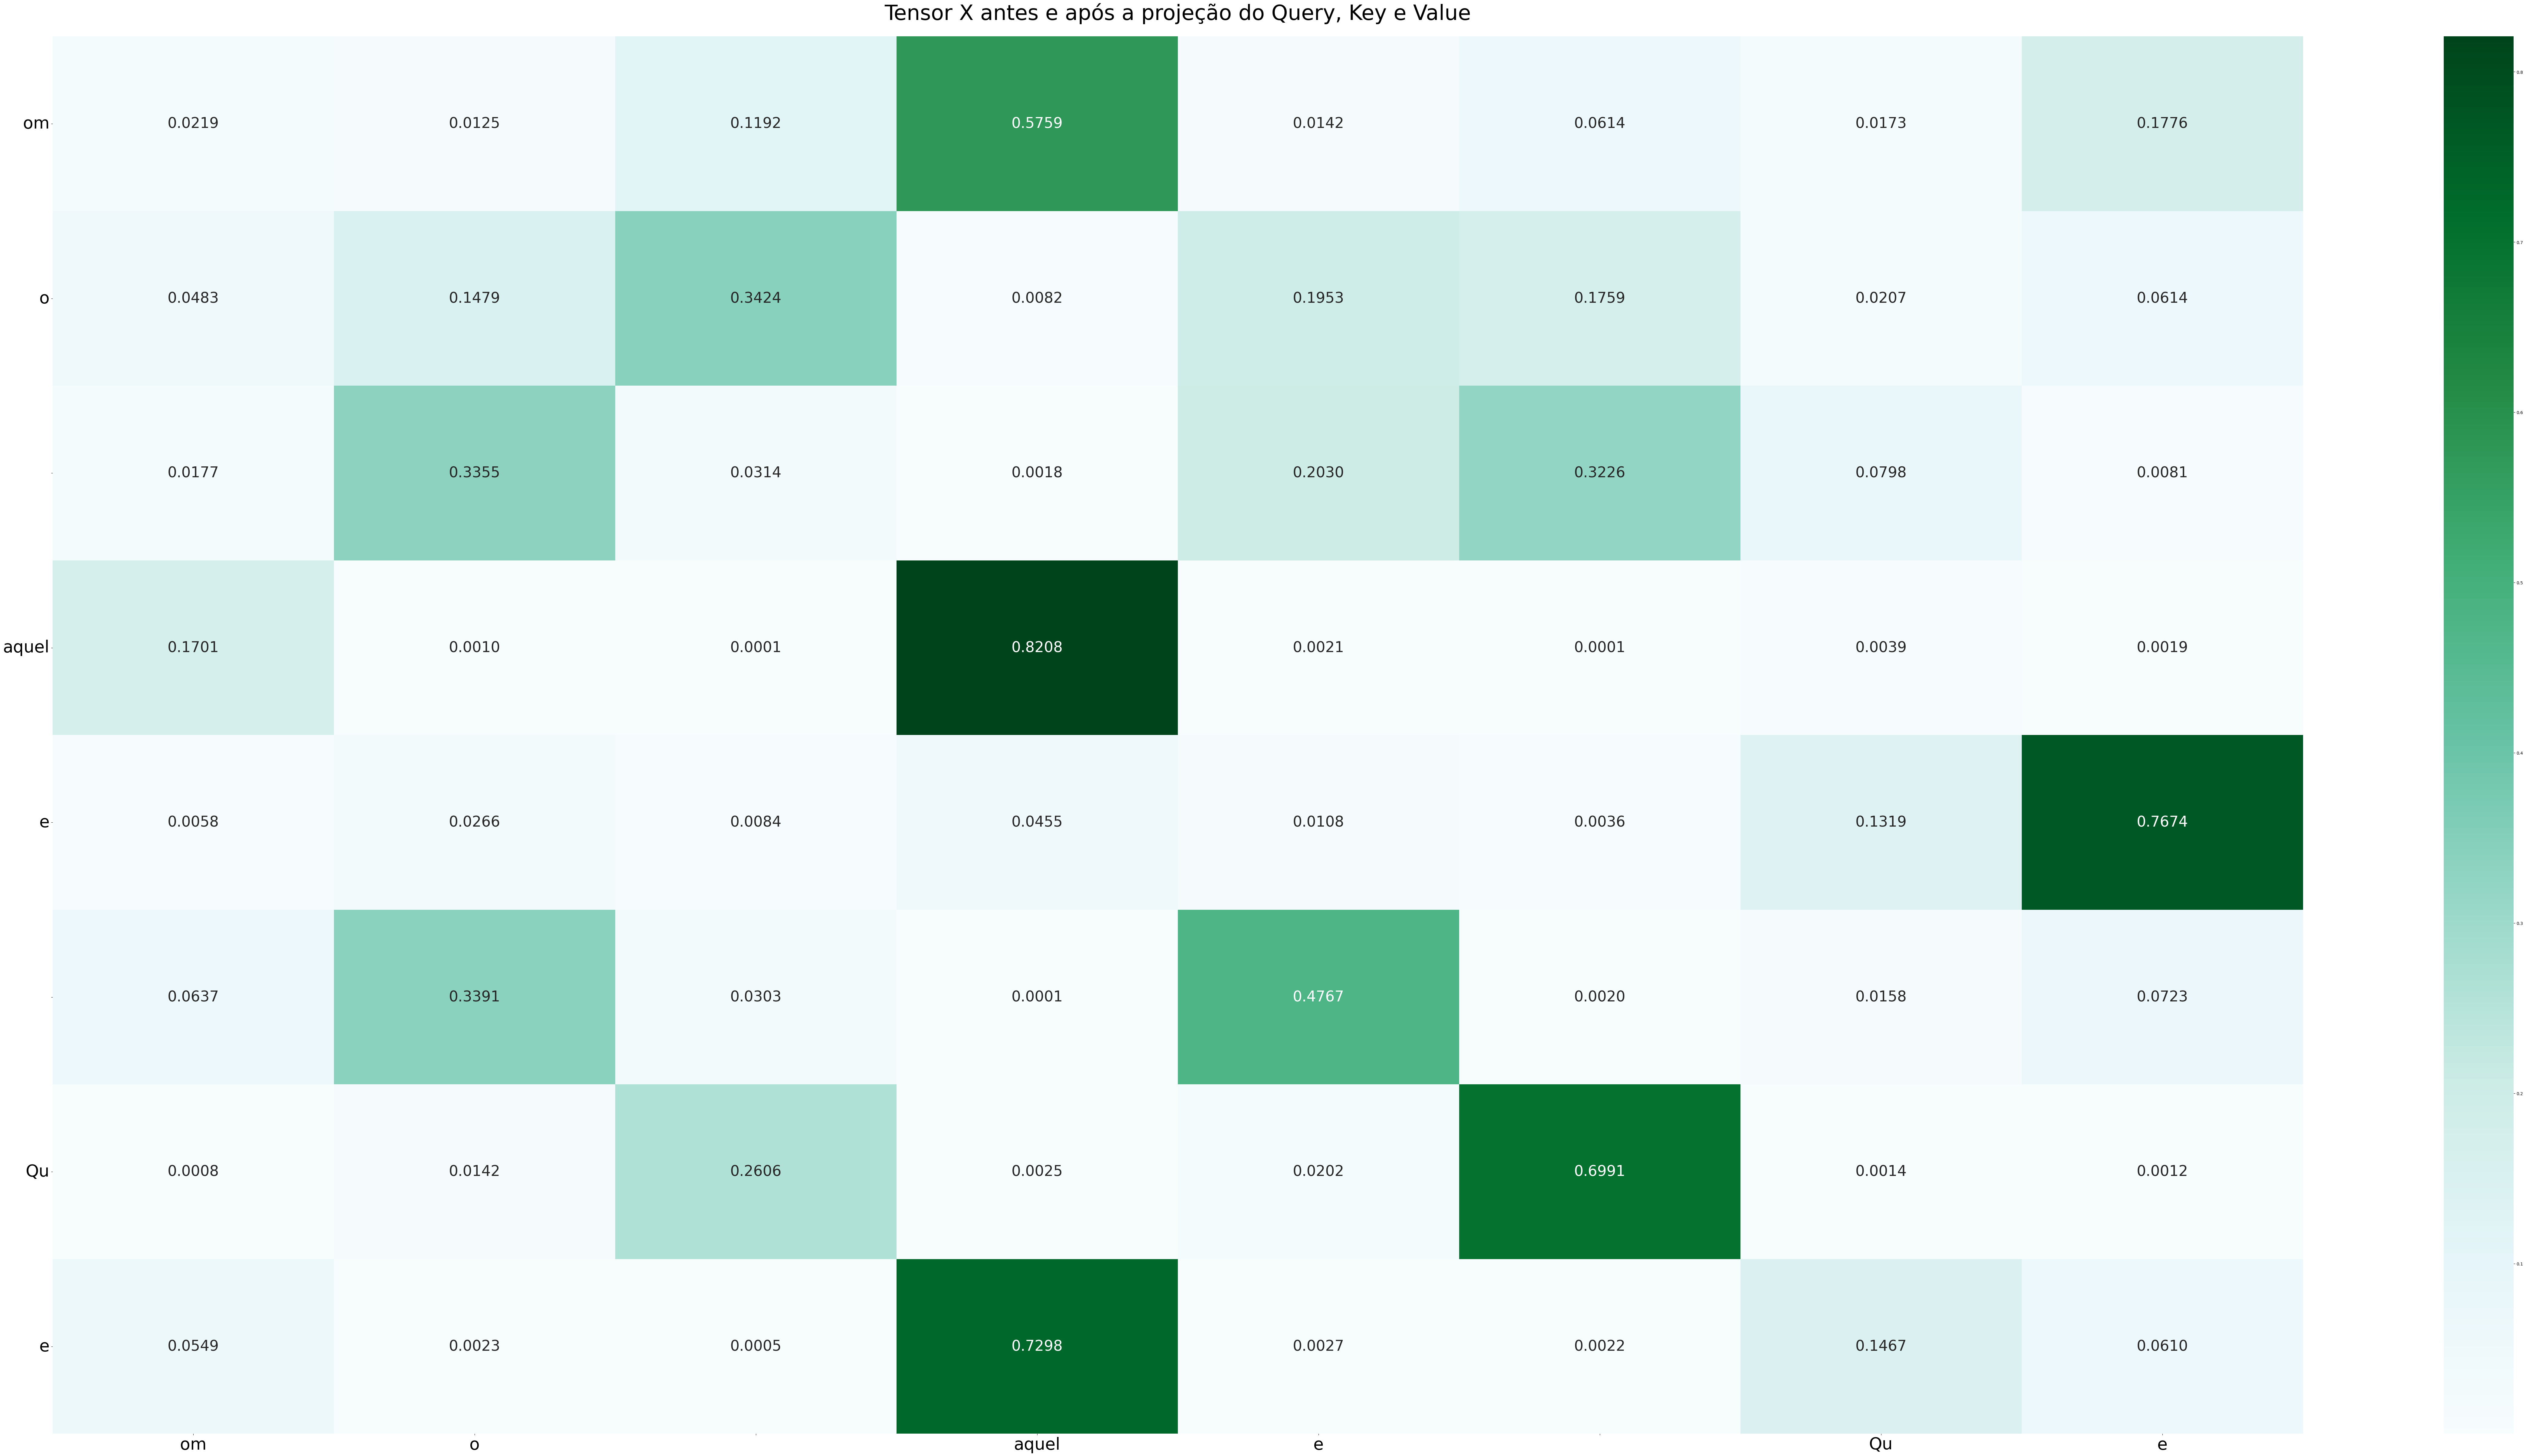

tensor([1122,  304,   65,    5,   57,  259,   65,    5])
tensor([0.1024, 0.0702, 0.0134, 0.3477, 0.0260, 0.0597, 0.1176, 0.2629],
       grad_fn=<SelectBackward0>)


In [400]:
tokkens = [Tokenizer.id_to_token(int(id)) for id in sda[3].tolist()]
attention_who = product_attention[3].detach().numpy()

plt.figure (figsize = (120, 60))
sns.heatmap(attention_who, xticklabels = tokkens, yticklabels = tokkens, cmap = "BuGn", annot = True, fmt = ".4f", annot_kws = {"size": 35})

plt.xticks (size = 40, rotation = 0)
plt.yticks (size = 40, rotation = 0)

plt.title("Tensor X antes e após a projeção do Query, Key e Value", size = 50, pad = 40)
plt.show()
